In [1]:
import numpy as np
import pandas as pd
from src.processing import calculate_fitness, find_pareto_front
from src.visualization import display_pareto_front, display_fitness_landscape_with_pareto, dividir_plot_regioes

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5

### Definindo sistema de equações por fitness/objetivo

In [10]:
total_records = 1000000


############################################
######################### Objetivo/fitness 1

equations1 = [

    # Funções gerais
    lambda x: 1.5 * np.sin(x/(total_records * 0.2)),   # eq0
    lambda x: np.cos(2 * x/(total_records * 0.1)),     # eq1
    lambda x: np.sin(4 * x/(total_records * 0.1)),     # eq2
    lambda x: 0.5 * np.sin(x/(total_records * 0.02)),  # eq3
    lambda x: 0.5 * np.sin(x/(total_records * 0.01)),  # eq4
    lambda x: 0.3 * np.sin(x/(total_records * 0.004)), # eq5
    lambda x: 0.2 * np.sin(x/(total_records * 0.002)), # eq6
    lambda x: 3 + 0.1 * x/total_records,               # eq7
    
    # Funções por região                               # eq8
    lambda x: np.select(
        [
            x < 0.2 * total_records,
            x < 0.4 * total_records,
            x < 0.6 * total_records,
            x < 0.8 * total_records,
            x <=      total_records,
        ],
        [-1   + 1   * np.sin(2 * x/(total_records * 0.1)), # 0%  - 20%  (região 1)
         -1.5 - 1   * np.sin(4 * x/(total_records * 0.1)), # 20% - 40%  (região 2)
         -0.5,                                             # 40% - 60%  (região 3)
         -0.2 + 1   * np.sin(1 * x/(total_records * 0.1)), # 60% - 80%  (região 4)
          0.8 + 1.5 * np.cos(2 * x/(total_records * 0.1))  # 80% - 100% (região 5)
        ], default=0
    ),
]


############################################
######################### Objetivo/fitness 2
equations2 = [


    # Funções gerais
    lambda x: 1.5 * np.cos(x/(total_records * 0.2)),   # eq0
#    lambda x: np.cos(2 * x/(total_records * 0.1)),     # eq1
#    lambda x: np.sin(4 * x/(total_records * 0.1)),     # eq2
#    lambda x: 0.5 * np.sin(x/(total_records * 0.02)),  # eq3
#    lambda x: 0.5 * np.sin(x/(total_records * 0.01)),  # eq4
#    lambda x: 0.3 * np.sin(x/(total_records * 0.004)), # eq5
#    lambda x: 0.2 * np.sin(x/(total_records * 0.002)), # eq6
#    lambda x: 3 + 0.1 * x/total_records,               # eq7
#    
#    # Funções por região                               # eq8
#    lambda x: np.select(
#        [
#            x < 0.2 * total_records,
#            x < 0.4 * total_records,
#            x < 0.6 * total_records,
#            x < 0.8 * total_records,
#            x <=      total_records,
#        ],
#        [-1   + 1   * np.sin(2 * x/(total_records * 0.1)), # 0%  - 20%  (região 1)
#         -1.5 - 1   * np.sin(4 * x/(total_records * 0.1)), # 20% - 40%  (região 2)
#         -0.5,                                             # 40% - 60%  (região 3)
#         -0.2 + 1   * np.sin(1 * x/(total_records * 0.1)), # 60% - 80%  (região 4)
#          0.8 + 1.5 * np.cos(2 * x/(total_records * 0.1))  # 80% - 100% (região 5)
#        ], default=0
#    ),
]

### Gerando dataframe com fitness landscape de 2 objetivos

In [11]:
# Criando dataframe com registros de 0 a 9.999.999
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
df = pd.DataFrame({'registro': registros})
print(f"Range: {registros[0]:,} até {registros[-1]:,}")

# Calculando fitness de forma matricial
df = calculate_fitness(equations1, equations2, df)
print(f"Colunas: {list(df.columns)}")

Range: 0 até 999,999
Colunas: ['registro', 'fitness1_eq0', 'fitness1_eq1', 'fitness1_eq2', 'fitness1_eq3', 'fitness1_eq4', 'fitness1_eq5', 'fitness1_eq6', 'fitness1_eq7', 'fitness1_eq8', 'fitness2_eq0', 'fitness1', 'fitness2', 'fitness_full']


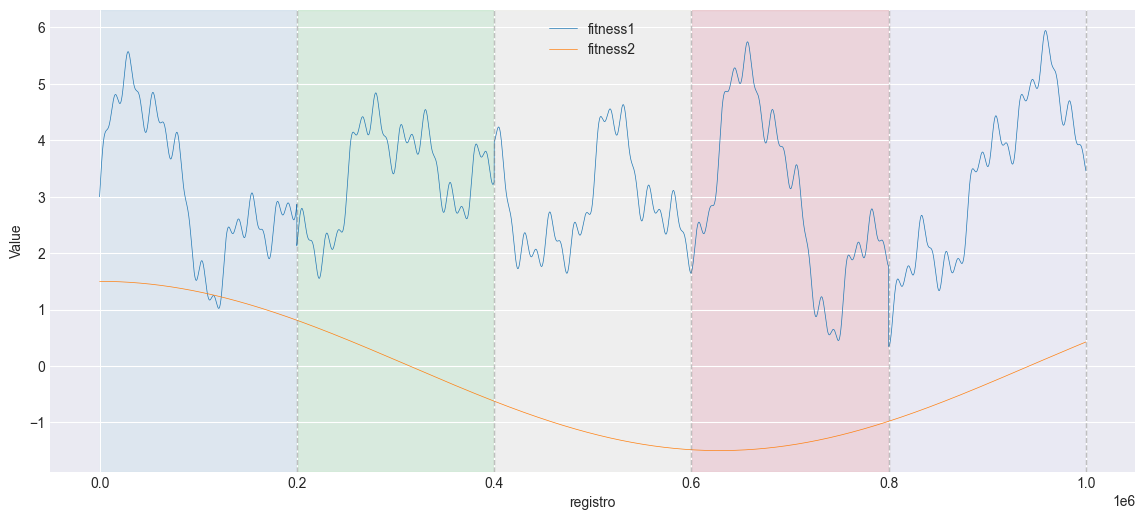

In [12]:
plt.plot(df['registro'], df['fitness1'], label='fitness1')
plt.plot(df['registro'], df['fitness2'], label='fitness2')

plt = dividir_plot_regioes(plt, df, n_regioes = 5)

plt.xlabel('registro')
plt.ylabel('Value')
plt.legend()
plt.show()

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


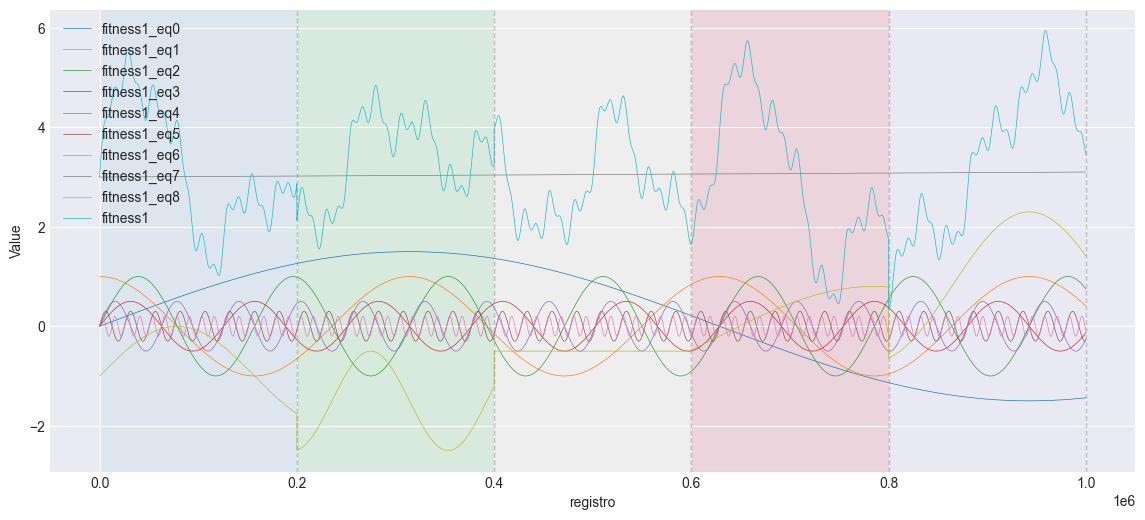

In [8]:
# Plot fitness1 and all fitness1 equations
fitness1_cols = [col for col in df.columns if 'fitness1' in col]
#fitness1_cols = ['fitness1','fitness1_eq2','fitness1_eq8']

for col in fitness1_cols:
    plt.plot(df['registro'], df[col], label=col)

plt = dividir_plot_regioes(plt, df, n_regioes = 5)

plt.xlabel('registro')
plt.ylabel('Value')
plt.legend()
plt.show()

In [6]:
# Filtrar apenas as colunas de equações (fitness1_eq0, fitness1_eq1, etc.)
fitness1_eq_cols = [col for col in df.columns if 'fitness1_eq' in col]

# Calcular correlação de cada equação com fitness1
correlacoes = {}
for col in fitness1_eq_cols:
    correlacao = df[col].corr(df['fitness1'])
    correlacoes[col] = correlacao

# Exibir resultados ordenados por correlação (do maior para o menor)
import pandas as pd
correlacoes_df = pd.DataFrame(list(correlacoes.items()), columns=['Equação', 'Correlação'])
correlacoes_df = correlacoes_df.sort_values('Correlação', ascending=False)

print("Correlação de cada equação com fitness1:")
print(correlacoes_df.to_string(index=False))

Correlação de cada equação com fitness1:
     Equação  Correlação
fitness1_eq0    0.679077
fitness1_eq3    0.382259
fitness1_eq1    0.357153
fitness1_eq4    0.280418
fitness1_eq8    0.179333
fitness1_eq5    0.170804
fitness1_eq6    0.118985
fitness1_eq7   -0.015981
fitness1_eq2   -0.025289


### Encontrando a fronteira de Pareto verdadeira

In [7]:
pareto_df = find_pareto_front(df)

# Salvando resultados
df.to_parquet('data/df3.parquet')
pareto_df.to_parquet('data/pareto_df3.parquet')

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 5,130 pontos.
Isso representa 0.5130% do espaço de busca.


### Análise visual dos resultados

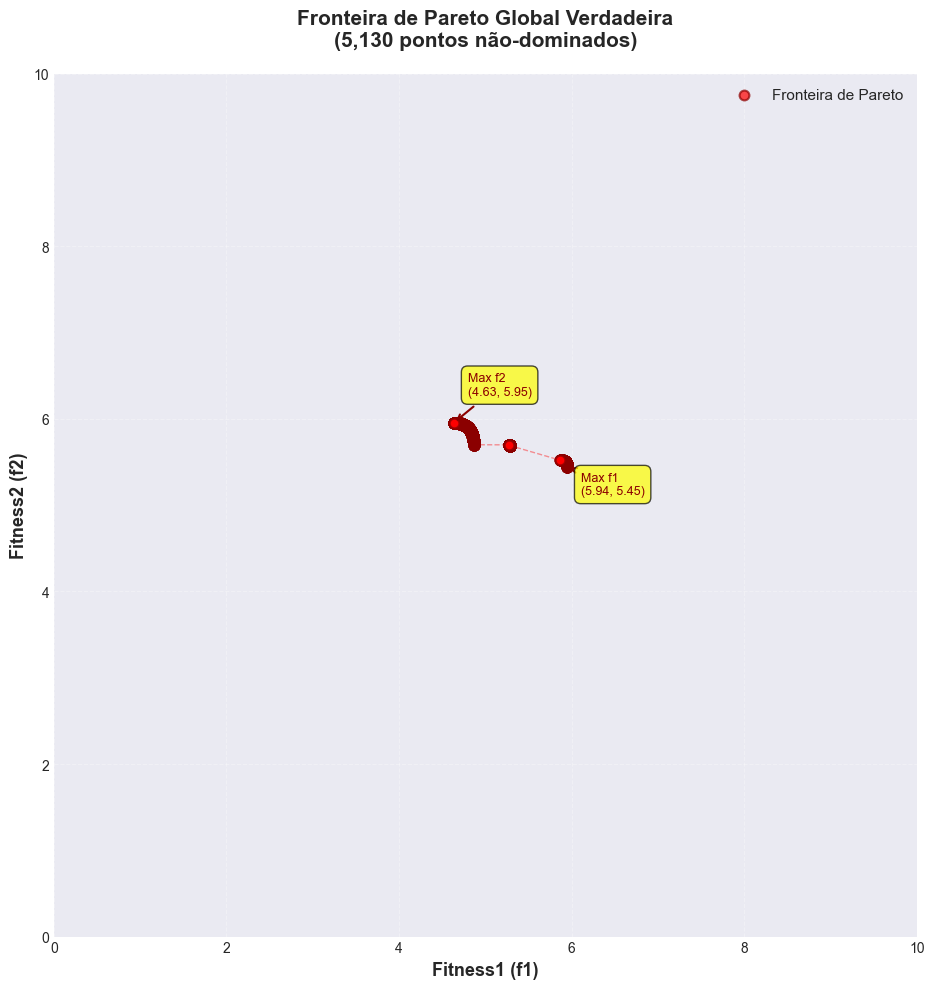


✅ Visualização concluída!


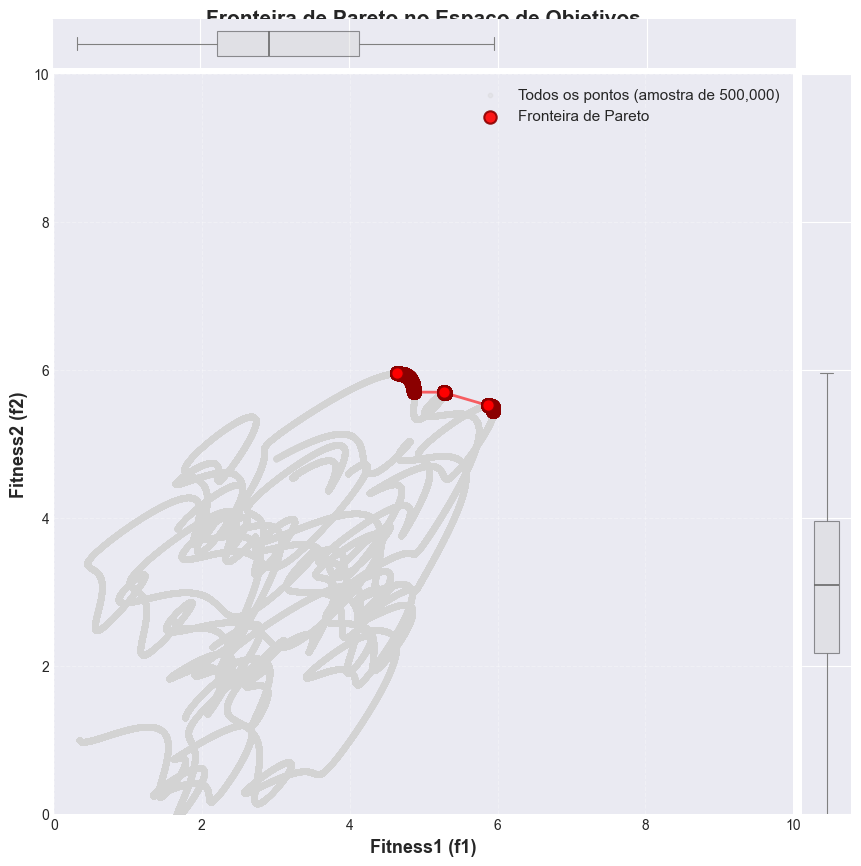

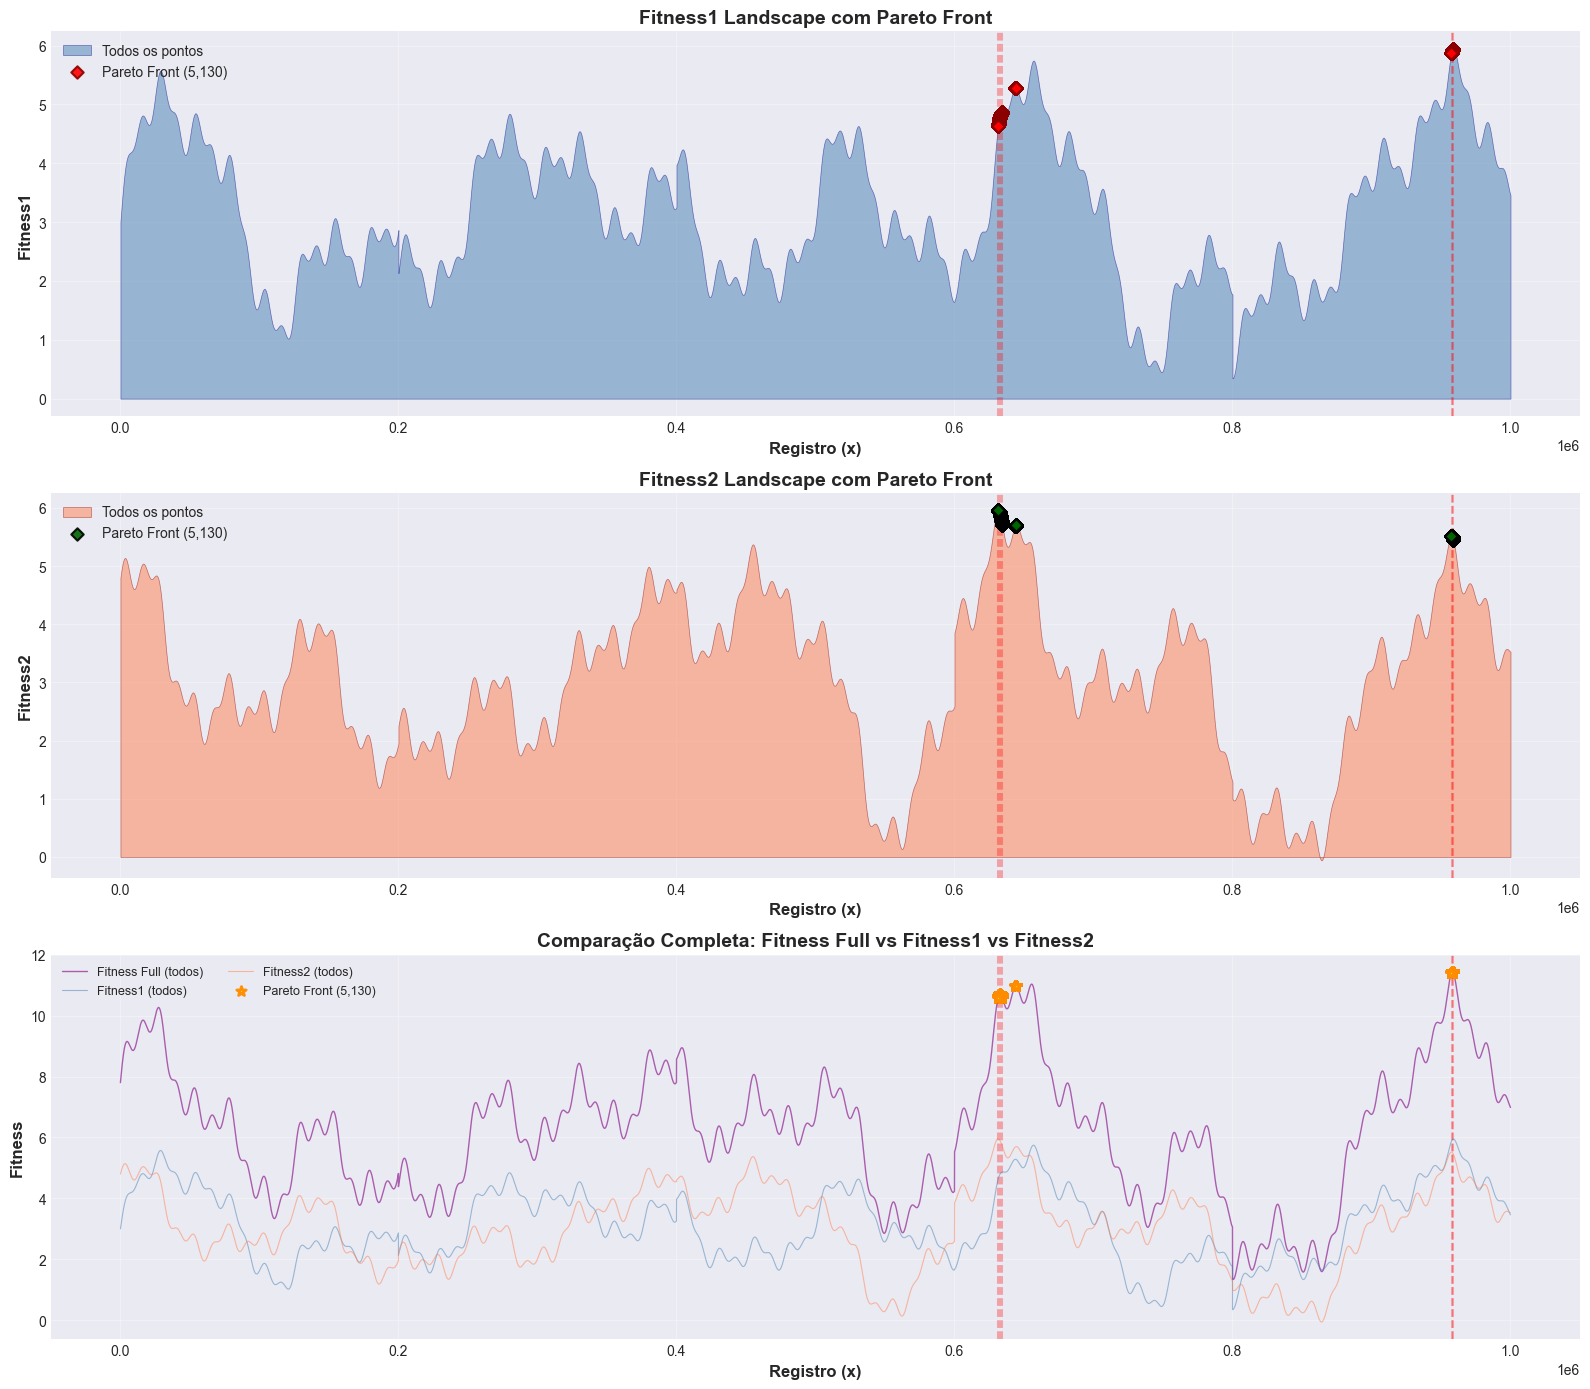

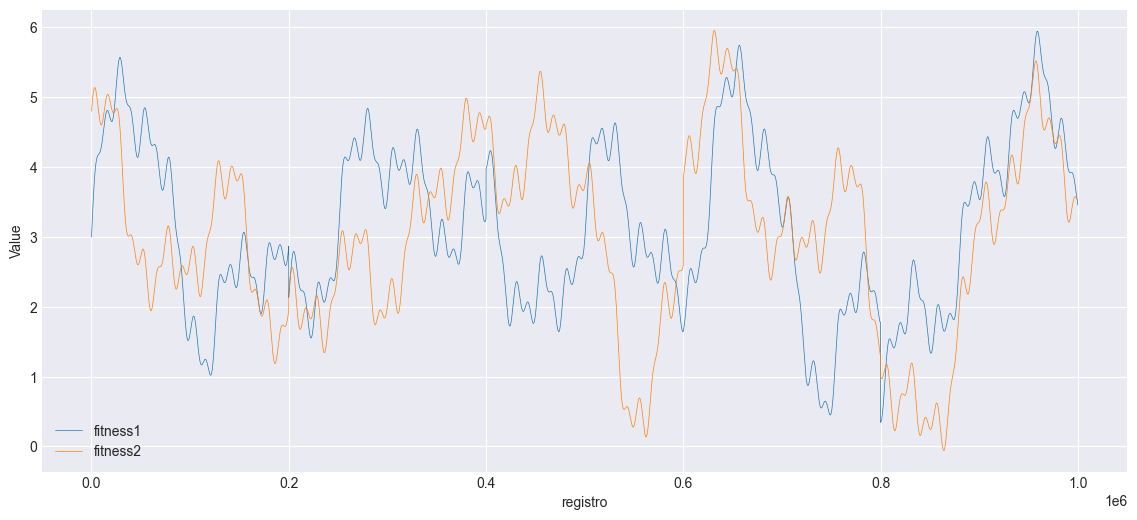

In [8]:
display_pareto_front(df, pareto_df)
display_fitness_landscape_with_pareto(df, pareto_df)


plt.plot(df['registro'], df['fitness1'], label='fitness1')
plt.plot(df['registro'], df['fitness2'], label='fitness2')

plt.xlabel('registro')
plt.ylabel('Value')
plt.legend()
plt.show()